# LangChain

**LangChain**: Build context-aware reasoning applications with LangChain's flexile framework tat leverages your company's data and APIs. Future-pof your application by making vendor optional part of your LLM infrastructure design.

**LagGraph**: Use LangGraph platform's APIs to design agent-driven user experience featuring human-in-the-loop, multi-agent collaboration, conversation history, long-term memory, and time-travel.. Deploy with fault-tolerant scalability

**LangSmith**: Get visibility into your LLM calls and agent reasoning with LangSmith to quickly debug failures. Run evals to assess yo agent performance over production traffic -- so you can ensure high-quality responses

* Agent workflows are represent as graphs
* State represents the current snapshot of the application
* Nodes are python function that represent agent logic. They receive the current state a input, do something, and return an updated state
* Edges are python functions that determine which node to execute next based on the state.They can be conditioned or fixed.

Five steps to the first graph:
1. Define the state class
2. Start the graph builder
3. Create Node
4. Create Edge
5. compile the graph

### State
* State is immutable
* For each field in your State, you can specify a special function called reducer
* When you return a new State, LangGraph uses the reducer to combine this field with existing  State
    * This enables LangGraph to run multiple nodes concurrently and combine State without overwriting

In [1]:
from typing import Annotated
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from dotenv import load_dotenv
from IPython.display import Image, display
import gradio as gr
from langgraph.graph import StateGraph
from langgraph.graph.message import add_messages
from langchain_openai import ChatOpenAI
from pydantic import BaseModel
import random

/Users/hanifemamgholizadeh/Desktop/Projects/Agent/.venv/lib/python3.13/site-packages/langgraph/cache/base/__init__.py:8: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


In [2]:
nouns = [
    "Cabbages",
    "Unicorns",
    "Toasters",
    "Penguins",
    "Bananas",
    "Zombies",
    "Rainbows",
    "Eels",
    "Pickles",
    "Muffins",
]
adjectives = [
    "outrageous",
    "smelly",
    "pedantic",
    "existential",
    "moody",
    "sparkly",
    "untrustworthy",
    "sarcastic",
    "squishy",
    "haunted",
]

In [3]:
load_dotenv(override=True)

True

### Step 1: Define the State object
You can use any python object; but it's most common to use a TypeDict or a Pydantic BaseModel

In [4]:
class State(BaseModel):
    messages: Annotated[list, add_messages]

## Step 2: start the Graph Builder with this State class

In [5]:
graph_builder = StateGraph(State)

In [6]:
def our_first_node(old_state: State) -> State:
    reply = f"{random.choice(nouns)} are {random.choice(adjectives)}"
    messages = [{"role": "assistant", "content": reply}]
    
    new_state = State(messages=messages)
    return new_state

graph_builder.add_node("first_node", our_first_node)

In [7]:

graph_builder.add_edge(START, "first_node")
graph_builder.add_edge("first_node", END)

In [8]:
graph = graph_builder.compile()

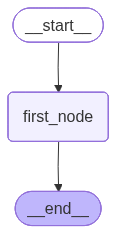

In [9]:
display(Image(graph.get_graph().draw_mermaid_png()))

In [11]:
def chat(user_input: str, history):
    message = {"role": "user", "content": user_input}
    messages = [message]
    state = State(messages=messages)
    result = graph.invoke(state)
    print(result)
    return result["messages"][-1].content


gr.ChatInterface(chat).launch()

* Running on local URL:  http://127.0.0.1:7861
* To create a public link, set `share=True` in `launch()`.


{'messages': [HumanMessage(content='Hi there', additional_kwargs={}, response_metadata={}, id='696e80b8-7c3f-478e-aed2-0c439e72fd30'), AIMessage(content='Rainbows are pedantic', additional_kwargs={}, response_metadata={}, id='b3c9d1f1-01e6-470e-a4a9-f48cbb5ef9e4', tool_calls=[], invalid_tool_calls=[])]}


In [12]:
class State(BaseModel):
    messages: Annotated[list, add_messages]

In [14]:
graph_builder = StateGraph(State)

In [15]:
llm = ChatOpenAI(model="gpt-4o-mini")


def chatbot_node(old_state: State) -> State:
    response = llm.invoke(old_state.messages)
    new_state = State(messages=[response])
    return new_state


graph_builder.add_node("chatbot", chatbot_node)

In [16]:
graph_builder.add_edge(START, "chatbot")
graph_builder.add_edge("chatbot", END)

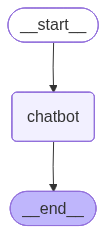

In [17]:
graph = graph_builder.compile()
display(Image(graph.get_graph().draw_mermaid_png()))

In [18]:
def chat(user_input: str, history):
    initial_state = State(messages=[{"role": "user", "content": user_input}])
    result = graph.invoke(initial_state)
    print(result)
    return result["messages"][-1].content


gr.ChatInterface(chat).launch()

* Running on local URL:  http://127.0.0.1:7862
* To create a public link, set `share=True` in `launch()`.


{'messages': [HumanMessage(content='Hi there', additional_kwargs={}, response_metadata={}, id='7f6bb15a-9975-41ad-a33e-15355662b73b'), AIMessage(content='Hello! How can I assist you today?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 9, 'prompt_tokens': 9, 'total_tokens': 18, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_a9ccf61ec1', 'id': 'chatcmpl-DkQ1YbLIshXlYJ1FThJF41OcnUdIk', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019e6d9d-6eff-7a63-b9a6-c2ef4893820b-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 9, 'output_tokens': 9, 'total_tokens': 18, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details

## Super-Step
A super-step can be considered a single iteration over the graph nodes. Nodes that run in parallel are part of the same super-step, while nodes that run sequentially belong to separate super-steps.

The graph describes one super-step; one interaction between agents and tools to achieve an outcome

Every user interaction is a fresh `graph.invoke()` call

The reducer handles updating state during a super-step but not between super-steps

In [1]:
from typing import Annotated
from langgraph.graph import StateGraph, START
from langgraph.graph.message import add_messages
from dotenv import load_dotenv
from IPython.display import Image, display
import gradio as gr
from langgraph.prebuilt import ToolNode, tools_condition
import requests
import os
from langchain_openai import ChatOpenAI
from typing import TypedDict

/Users/hanifemamgholizadeh/Desktop/Projects/Agent/.venv/lib/python3.13/site-packages/langgraph/cache/base/__init__.py:8: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


In [3]:
load_dotenv(override=True)

True

In [4]:
from langchain_community.utilities import GoogleSerperAPIWrapper

serper = GoogleSerperAPIWrapper()
serper.run("What is the capital of France?")

'Paris'

In [8]:
from langchain_core.tools import Tool

tool_search = Tool(
    name="search",
    func=serper.run,
    description="Useful for when you need more information from an online search",
)

In [9]:
tool_search.invoke("What is the capital of France?")

'Paris'

In [11]:
pushover_token = os.getenv("PUSHOVER_TOKEN")
pushover_user = os.getenv("PUSHOVER_USER")
pushover_url = "https://api.pushover.net/1/messages.json"


def push(text: str):
    """Send a push notification to the user"""
    requests.post(
        pushover_url,
        data={"token": pushover_token, "user": pushover_user, "message": text},
    )

In [12]:
from langchain_core.tools import Tool

tool_push = Tool(
    name="send_push_notification",
    func=push,
    description="useful for when you want to send a push notification",
)

tool_push.invoke("Hello, me")

In [13]:
class State(TypedDict):
    messages: Annotated[list, add_messages]

In [16]:
tools = [tool_search, tool_push]

In [14]:
graph_builder = StateGraph(State)

When we implement tools, we always need to make 2 changes to the code:
1. Changes to provide the tools to OpenAI in json when we make the call
2. Changes to handle the results back: look for the model staying that the `finish_reason=="tool_calls"` and then retrieve the call, run the function provide the results

In [17]:
llm = ChatOpenAI(model="gpt-4o-mini")
llm_with_tools = llm.bind_tools(tools)

In [18]:
def chatbot(state: State):
    return{"messages":[llm_with_tools.invoke(state["messages"])]}

graph_builder.add_node("chatbot", chatbot)
graph_builder.add_node("tools", ToolNode(tools=tools))

In [20]:
graph_builder.add_conditional_edges("chatbot", tools_condition, "tools")

graph_builder.add_edge("tools", "chatbot")
graph_builder.add_edge(START, "chatbot")

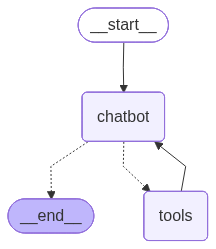

In [21]:
graph = graph_builder.compile()
display(Image(graph.get_graph().draw_mermaid_png()))